In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
dataset=pd.read_csv("Salary_Data.csv")
print(dataset)

    YearsExperience    Salary
0               1.1   39343.0
1               1.3   46205.0
2               1.5   37731.0
3               2.0   43525.0
4               2.2   39891.0
5               2.9   56642.0
6               3.0   60150.0
7               3.2   54445.0
8               3.2   64445.0
9               3.7   57189.0
10              3.9   63218.0
11              4.0   55794.0
12              4.0   56957.0
13              4.1   57081.0
14              4.5   61111.0
15              4.9   67938.0
16              5.1   66029.0
17              5.3   83088.0
18              5.9   81363.0
19              6.0   93940.0
20              6.8   91738.0
21              7.1   98273.0
22              7.9  101302.0
23              8.2  113812.0
24              8.7  109431.0
25              9.0  105582.0
26              9.5  116969.0
27              9.6  112635.0
28             10.3  122391.0
29             10.5  121872.0


In [3]:
x=dataset.iloc[:,0].values
y=dataset.iloc[:,1].values
print(x)
print(y)

[ 1.1  1.3  1.5  2.   2.2  2.9  3.   3.2  3.2  3.7  3.9  4.   4.   4.1
  4.5  4.9  5.1  5.3  5.9  6.   6.8  7.1  7.9  8.2  8.7  9.   9.5  9.6
 10.3 10.5]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)

In [5]:
print(dataset.shape)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(30, 2)
(20,)
(10,)
(20,)
(10,)


In [6]:
x_mean=np.mean(X_train)
y_mean=np.mean(y_train)
print(x_mean)
print(y_mean)

4.7299999999999995
71022.5


In [7]:
n=len(X_train)
num,den=0,0
for i in range(n):
  num+=(X_train[i]-x_mean)*(y_train[i]-y_mean)
  den+=(X_train[i]-x_mean)**2
b1=num/den
b0=y_mean-(b1*x_mean)
print("Intercept=",b0)
print("Coefficient=",b1)


Intercept= 26816.19224403117
Coefficient= 9345.942443122376


In [8]:
y_pred_code=b0+b1*X_test
print(y_pred_code)


[ 40835.10590871 123079.39940819  65134.55626083  63265.36777221
 115602.64545369 108125.8914992  116537.23969801  64199.96201652
  76349.68719258 100649.1375447 ]


In [9]:
print(y_test)

[ 37731. 122391.  57081.  63218. 116969. 109431. 112635.  55794.  83088.
 101302.]


In [10]:
#mean square error
n1=len(y_test)
mse=0
for i in range(n1):
  mse+=(y_test[i]-y_pred_code[i])**2
mse=mse/n1
print("Mean square error =",mse)
#root mean square error
rmse=np.sqrt(mse)
print("Root mean square error =",rmse)

Mean square error = 21026037.329511303
Root mean square error = 4585.415720467589


In [11]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()


In [12]:
reg.fit(X_train.reshape(-1, 1), y_train)

LinearRegression()

In [13]:
y_pred=reg.predict(X_test.reshape(-1,1))

In [14]:
print("Intercept=",reg.intercept_)
print("Coefficient=",reg.coef_)

Intercept= 26816.192244031183
Coefficient= [9345.94244312]


In [15]:
from sklearn import metrics
print("Mean absolute error =",metrics.mean_absolute_error(y_test,y_pred))
print("Mean squared error =",metrics.mean_squared_error(y_test,y_pred))
print("Root mean squared error =",np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

Mean absolute error = 3426.4269374307078
Mean squared error = 21026037.329511296
Root mean squared error = 4585.4157204675885


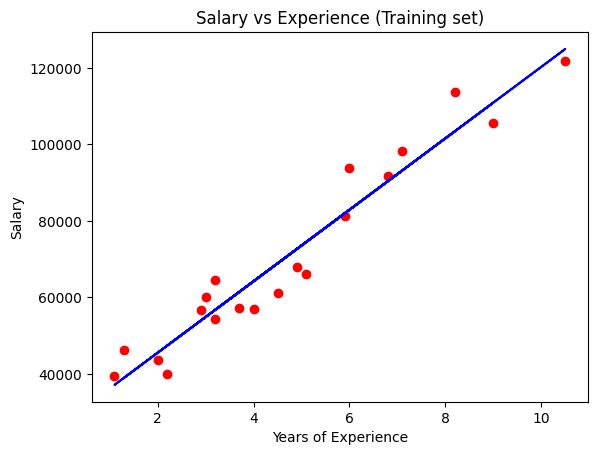

In [16]:
plt.scatter(X_train,y_train,color="red")
plt.plot(X_train,reg.predict(X_train.reshape(-1,1)),color="blue")
plt.title("Salary vs Experience (Training set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

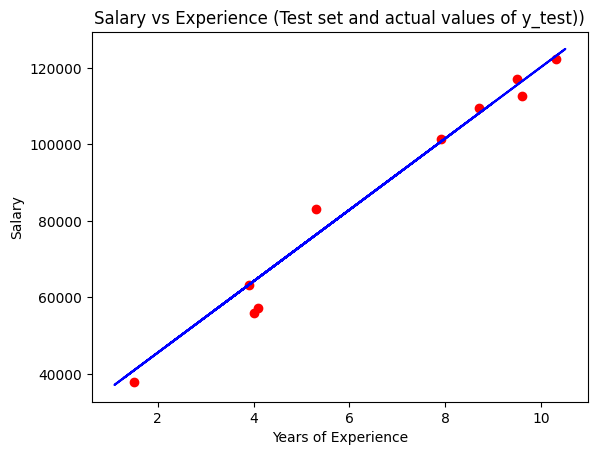

In [17]:
plt.scatter(X_test,y_test,color="red")
plt.plot(X_train,reg.predict(X_train.reshape(-1,1)),color="blue")
plt.title("Salary vs Experience (Test set and actual values of y_test))")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

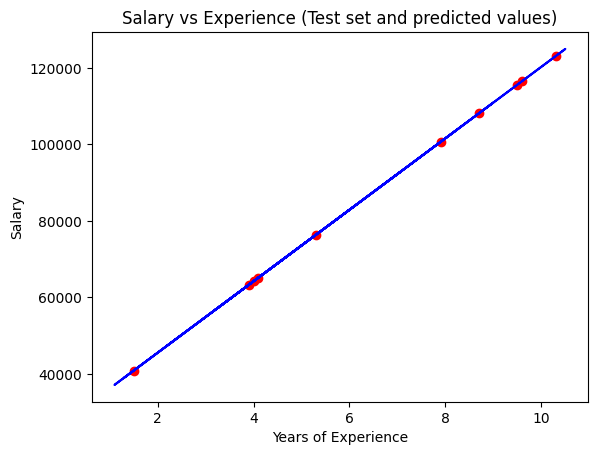

In [18]:
plt.scatter(X_test,y_pred,color="red")
plt.plot(X_train,reg.predict(X_train.reshape(-1,1)),color="blue")
plt.title("Salary vs Experience (Test set and predicted values)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()